In [1]:
# ============================================================
# BLOQUE 1 — CARGA ROBUSTA DEL EXPERIMENTO
# ============================================================

import os
import sys
import glob
import yaml
import joblib
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# ROOT
# ------------------------------------------------------------

project_root = os.path.abspath('../../')

if project_root not in sys.path:
    sys.path.append(project_root)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def clean_path(yaml_path, root):
    limpio = yaml_path.replace('../../', '').replace('../', '')
    return os.path.normpath(os.path.join(root, limpio))

# ------------------------------------------------------------
# YAML DEL EXPERIMENTO
# ------------------------------------------------------------

yaml_path = '../../configs/experiments/feat_task_k3_diag_pca90_hjorthonly.yaml'

with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']

n_states = cfg['pipeline']['hmm']['k_states']

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

out_dir_base = clean_path(cfg['paths']['output_dir'], project_root)

exp_dir = os.path.join(out_dir_base, exp_name)

features_dir = clean_path(cfg['paths']['features_dir'], project_root)

# ------------------------------------------------------------
# LOAD VITERBI
# ------------------------------------------------------------

viterbi_paths = np.load(
    os.path.join(
        exp_dir,
        f'viterbi_paths_k{n_states}.npy'
    )
)

# ------------------------------------------------------------
# LOAD FEATURES
# ------------------------------------------------------------

feature_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_features.npy')
    )
)

X_original = np.vstack([
    np.load(f)
    for f in feature_files
])

# ------------------------------------------------------------
# LOAD SCALER
# ------------------------------------------------------------

scaler = joblib.load(
    os.path.join(exp_dir, 'scaler.pkl')
)

X_scaled = scaler.transform(X_original)

# ------------------------------------------------------------
# CHECKS
# ------------------------------------------------------------

print("=" * 60)
print("DEBUG DATA")
print("=" * 60)

print(f"Experiment: {exp_name}")
print(f"X_original: {X_original.shape}")
print(f"X_scaled:   {X_scaled.shape}")
print(f"Viterbi:    {viterbi_paths.shape}")

assert X_scaled.shape[0] == len(viterbi_paths)

print("\nCarga completada correctamente.")

DEBUG DATA
Experiment: feat_task_k3_diag_pca90_hjorthonly
X_original: (143899, 38)
X_scaled:   (143899, 38)
Viterbi:    (143899,)

Carga completada correctamente.


Cargando experimento: feat_task_k3_diag_pca90_hjorthonly
Estados HMM: 3
Sujetos cargados: 118

Reconstruyendo épocas...

Ventanas por época detectadas: 61
GO: 1179 épocas
NOGO: 1180 épocas
ADULTO_GO: 599 épocas
ADULTO_NOGO: 600 épocas
ADOLESCENTE_GO: 580 épocas
ADOLESCENTE_NOGO: 580 épocas

TIME AXIS
Inicio real: -400.0 ms
Final real: 5600.0 ms


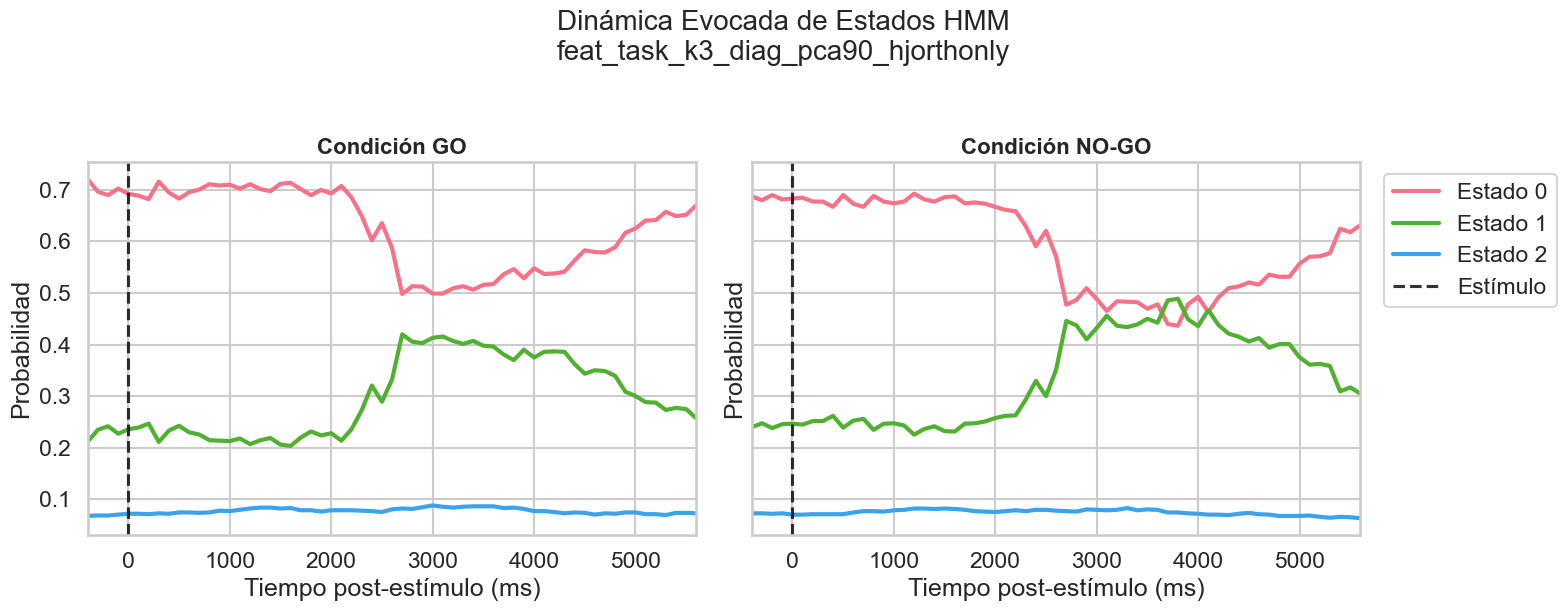

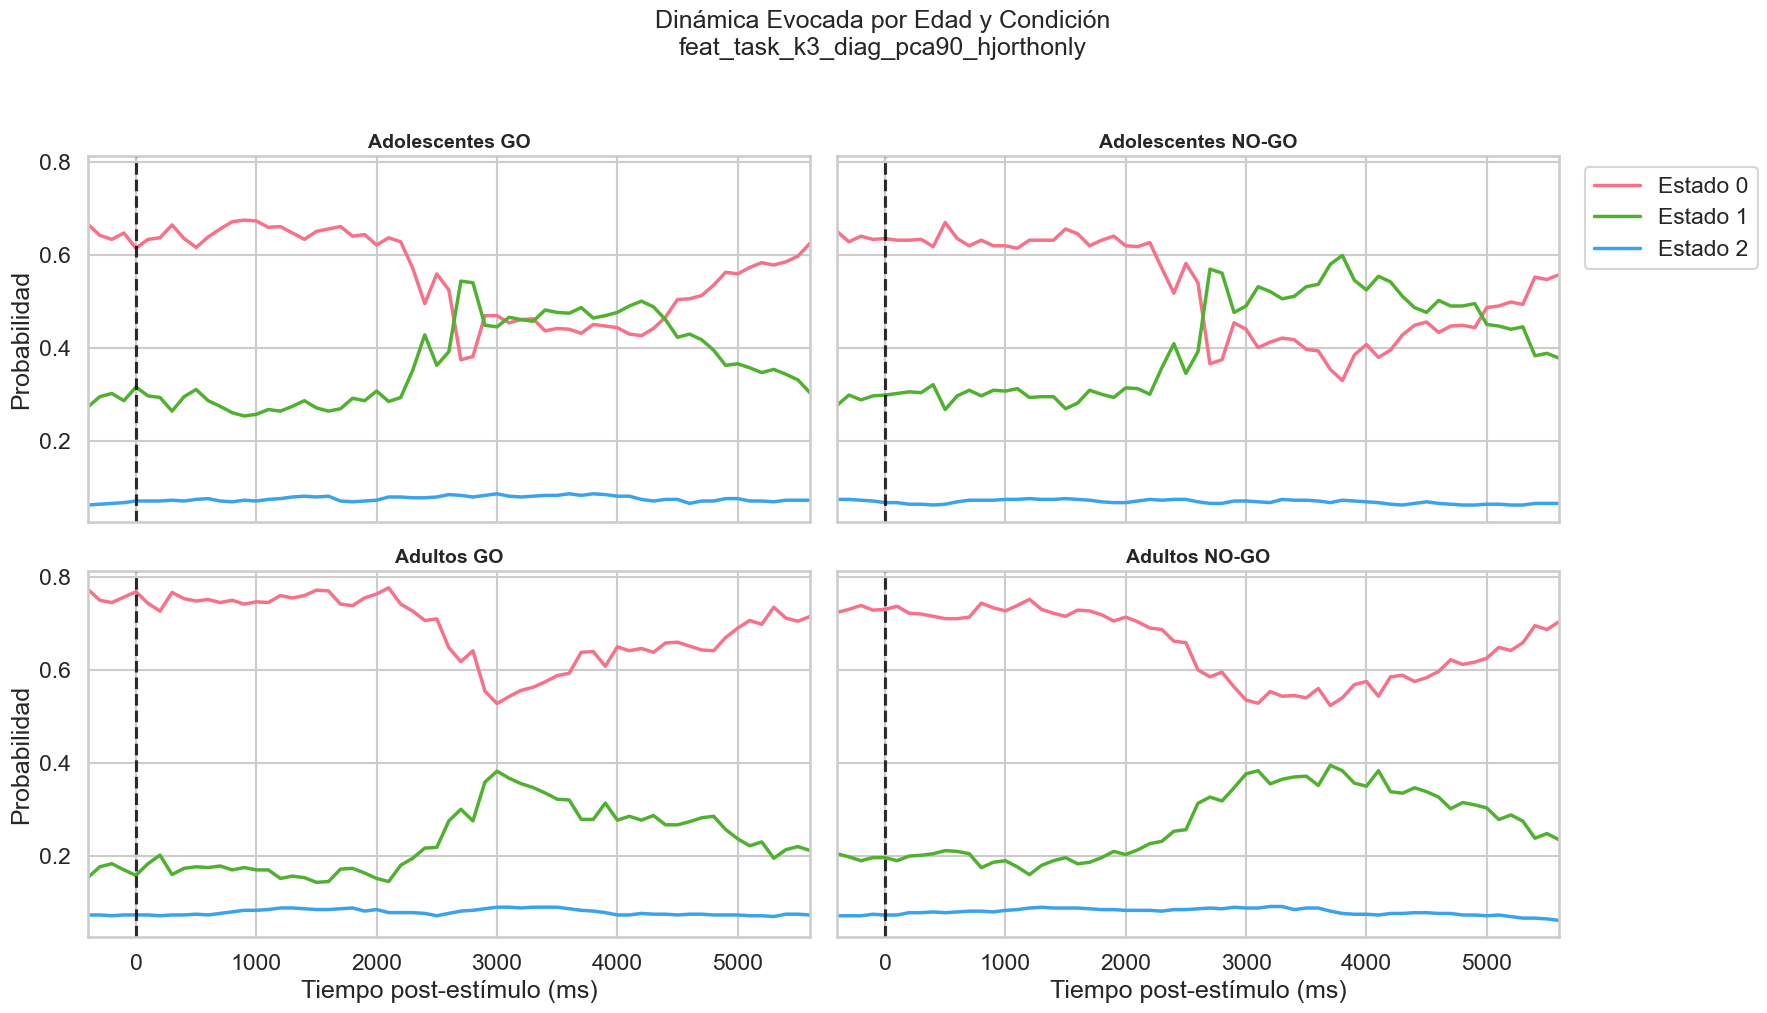


PEAK EVOKED PROBABILITIES


,Group,State,Peak Time (ms),Peak Probability
0,GO,0,-400.0,0.720102
1,GO,1,2700.0,0.419847
2,GO,2,3000.0,0.088210
3,NOGO,0,1200.0,0.692373
4,NOGO,1,3800.0,0.488983
5,NOGO,2,3300.0,0.083051
6,ADULTO_GO,0,2100.0,0.776294
7,ADULTO_GO,1,3000.0,0.382304
8,ADULTO_GO,2,3000.0,0.090150
9,ADULTO_NOGO,0,1200.0,0.751667


In [4]:
# ============================================================
# EVOKED STATE DYNAMICS (GO vs NO-GO)
# VERSIÓN CORREGIDA — ALINEACIÓN TEMPORAL REAL
# ============================================================

import os
import glob
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# ============================================================
# CONFIG
# ============================================================

CONFIG_PATH = "../../configs/experiments/feat_task_k3_diag_pca90_hjorthonly.yaml"

# ------------------------------------------------------------
# PARÁMETROS TEMPORALES REALES
# ------------------------------------------------------------

EPOCH_START_MS = -500
WINDOW_SIZE_MS = 200
STEP_SIZE_MS = 100

LISTA_ADULTOS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN', 'GSASC', 'IJALSC',
    'JAGSSC', 'LHACSIN', 'MAEGLSC', 'MAHLSC', 'MFGSIN', 'MGOKSC',
    'RAMPSIN', 'SDBGSIN', 'VMRSIN', 'AVLLSC', 'BMPSC', 'CGMSIN',
    'CJGSIN', 'CPGSC', 'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN',
    'JGCSC', 'MGVGSC', 'RKACSC', 'SEOOSIN', 'TTOSC', 'VBPSIN'
]

# ============================================================
# LOAD EXPERIMENT
# ============================================================

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']
k = cfg['pipeline']['hmm']['k_states']

exp_dir = os.path.join(
    "../../outputs/processed/experiments/feature_hmm/task/",
    exp_name
)

features_dir = "../../data/interim/features/task/"

print("=" * 60)
print(f"Cargando experimento: {exp_name}")
print("=" * 60)

viterbi = np.load(
    os.path.join(exp_dir, f'viterbi_paths_k{k}.npy')
)

length_files = sorted(
    glob.glob(os.path.join(features_dir, '*_lengths.npy'))
)

print(f"Estados HMM: {k}")
print(f"Sujetos cargados: {len(length_files)}")

# ============================================================
# HELPERS
# ============================================================

def parse_subject_info(filename):

    clean_name = filename.upper()

    clean_name = clean_name.replace('_SIN_CONTEXTO', '')
    clean_name = clean_name.replace('_EPO', '')
    clean_name = clean_name.replace('_LENGTHS.NPY', '')
    clean_name = clean_name.replace('.NPY', '')

    if clean_name.endswith("NOGO"):
        condicion = "NOGO"
        subject_id_real = clean_name[:-4]

    elif clean_name.endswith("NG"):
        condicion = "NOGO"
        subject_id_real = clean_name[:-2]

    elif clean_name.endswith("GO"):
        condicion = "GO"
        subject_id_real = clean_name[:-2]

    else:
        condicion = "GO"
        subject_id_real = clean_name

    grupo = "ADOLESCENTE"

    for adulto in LISTA_ADULTOS:
        if subject_id_real.startswith(adulto):
            grupo = "ADULTO"
            break

    return subject_id_real, grupo, condicion


def calcular_probabilidades(matriz, n_states):

    if len(matriz) == 0:
        return np.zeros((n_states, WINDOWS_PER_EPOCH))

    probs = np.zeros((n_states, matriz.shape[1]))

    for s in range(n_states):
        probs[s] = np.mean(matriz == s, axis=0)

    return probs

# ============================================================
# RECONSTRUCCIÓN DE SECUENCIAS
# ============================================================

print("\nReconstruyendo épocas...")

secuencias_crudas = {
    "GO": [],
    "NOGO": [],
    "ADULTO_GO": [],
    "ADULTO_NOGO": [],
    "ADOLESCENTE_GO": [],
    "ADOLESCENTE_NOGO": []
}

start_idx = 0
todas_las_longitudes = []

for f_path in length_files:

    filename = os.path.basename(f_path)

    subject_id_real, grupo, condicion = parse_subject_info(filename)

    lengths = np.load(f_path)

    for ep_len in lengths:

        ep_path = viterbi[start_idx:start_idx + ep_len]

        start_idx += ep_len

        todas_las_longitudes.append(ep_len)

        secuencias_crudas[condicion].append(ep_path)

        secuencias_crudas[f"{grupo}_{condicion}"].append(ep_path)

# ============================================================
# DETECCIÓN AUTOMÁTICA DE TAMAÑO DE ÉPOCA
# ============================================================

WINDOWS_PER_EPOCH = Counter(
    todas_las_longitudes
).most_common(1)[0][0]

print(f"\nVentanas por época detectadas: {WINDOWS_PER_EPOCH}")

# ============================================================
# FILTRAR ÉPOCAS VÁLIDAS
# ============================================================

matrices = {}

for key, lista_epocas in secuencias_crudas.items():

    epocas_validas = [
        ep for ep in lista_epocas
        if len(ep) == WINDOWS_PER_EPOCH
    ]

    matrices[key] = np.array(epocas_validas)

    print(f"{key}: {len(epocas_validas)} épocas")

# ============================================================
# EJE TEMPORAL CORRECTO
# ============================================================

time_axis = (
    np.arange(WINDOWS_PER_EPOCH) * STEP_SIZE_MS
    + EPOCH_START_MS
    + (WINDOW_SIZE_MS / 2)
)

print("\n" + "=" * 60)
print("TIME AXIS")
print("=" * 60)

print(f"Inicio real: {time_axis[0]} ms")
print(f"Final real: {time_axis[-1]} ms")

# ============================================================
# PROBABILIDADES EVOCADAS
# ============================================================

probs = {
    key: calcular_probabilidades(value, k)
    for key, value in matrices.items()
}

# ============================================================
# PLOT 1 — GO vs NOGO
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

colors = sns.color_palette("husl", k)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True,
    sharex=True
)

paneles = [
    ("GO", "Condición GO"),
    ("NOGO", "Condición NO-GO")
]

for ax, (key, title) in zip(axes, paneles):

    matriz = probs[key]

    for s in range(k):

        ax.plot(
            time_axis,
            matriz[s],
            lw=3,
            label=f"Estado {s}",
            color=colors[s]
        )

    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel("Tiempo post-estímulo (ms)")
    ax.set_ylabel("Probabilidad")

    # ESTÍMULO REAL
    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black',
        label='Estímulo'
    )

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Dinámica Evocada de Estados HMM\n{exp_name}",
    fontsize=20,
    y=1.03
)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2 — MATRIZ 2x2 DESARROLLO
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 10),
    sharex=True,
    sharey=True
)

config_panels = [
    (0, 0, "ADOLESCENTE_GO", "Adolescentes GO"),
    (0, 1, "ADOLESCENTE_NOGO", "Adolescentes NO-GO"),
    (1, 0, "ADULTO_GO", "Adultos GO"),
    (1, 1, "ADULTO_NOGO", "Adultos NO-GO")
]

for row, col, key, title in config_panels:

    ax = axes[row, col]

    matriz = probs[key]

    for s in range(k):

        ax.plot(
            time_axis,
            matriz[s],
            lw=2.5,
            label=f"Estado {s}",
            color=colors[s]
        )

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black'
    )

    if row == 1:
        ax.set_xlabel("Tiempo post-estímulo (ms)")

    if col == 0:
        ax.set_ylabel("Probabilidad")

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[0,1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Dinámica Evocada por Edad y Condición\n{exp_name}",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# MÉTRICAS TEMPORALES RESUMEN
# ============================================================

print("\n" + "=" * 60)
print("PEAK EVOKED PROBABILITIES")
print("=" * 60)

summary = []

for group_name, matrix in probs.items():

    if matrix.shape[1] == 0:
        continue

    for s in range(k):

        peak_idx = np.argmax(matrix[s])

        peak_time = time_axis[peak_idx]

        peak_prob = matrix[s, peak_idx]

        summary.append({
            'Group': group_name,
            'State': s,
            'Peak Time (ms)': peak_time,
            'Peak Probability': peak_prob
        })

df_summary = pd.DataFrame(summary)

display(df_summary)